In [1]:
%mkdir data_hmdb51

In [5]:
!unzip -q hmdb51.zip -d data_hmdb51

In [2]:
import os

data_dir = "data_hmdb51/hmdb51"
classes = os.listdir(data_dir)
print("Number of classes: ",len(classes))

Number of classes:  51


In [3]:
count_dict = dict()
total_videos = 0

for class_name in classes:
    cls_dir = os.path.join(data_dir, class_name)
    num_samples = len(os.listdir(cls_dir))
    count_dict[class_name] = num_samples
    total_videos += num_samples

total_videos

6754

In [21]:
sorted_count_dict = dict(sorted(count_dict.items(), key=lambda item: item[1], reverse=True))

Text(0.5, 1.0, 'Dictionary Sorted by Values')

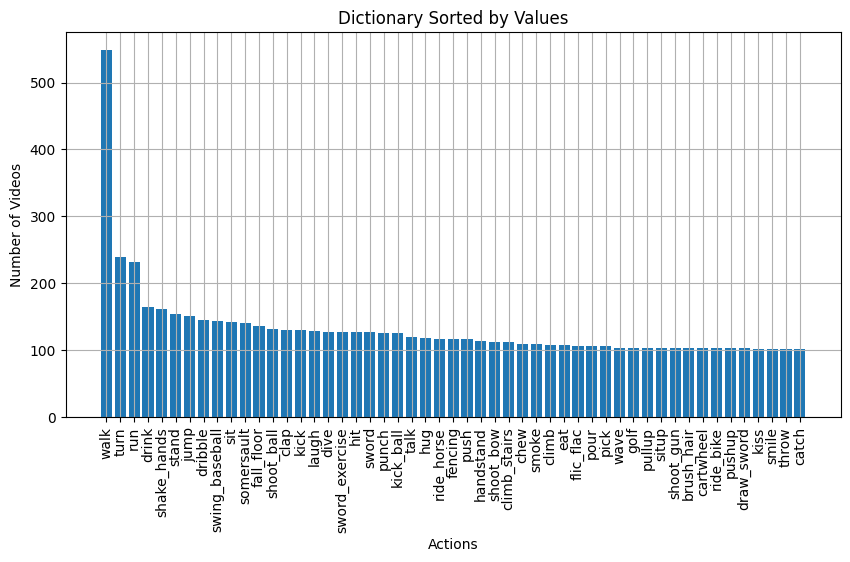

In [22]:
import matplotlib.pyplot as plt

# Separate keys and values
keys = sorted_count_dict.keys()
values = sorted_count_dict.values()

# Plot
plt.figure(figsize=(10,5))
plt.bar(keys, values)
plt.grid()

plt.xlabel("Actions")
plt.ylabel("Number of Videos")
plt.xticks(rotation=90)
plt.title("Dictionary Sorted by Values")

In [25]:
import cv2
from collections import defaultdict

# Counters
format_count = defaultdict(int)
fps_count = defaultdict(int)
resolution_count = defaultdict(int)
duration_count = defaultdict(int)  # optional grouping

for class_name in classes:
    cls_dir = os.path.join(data_dir, class_name)
    videos = os.listdir(cls_dir)
    for video_name in videos:
        video_dir = os.path.join(cls_dir, video_name)
        cap = cv2.VideoCapture(video_dir)
    
        if not cap.isOpened():
            print(f"Cannot open {video_dir}")
            continue

        # Extract info
        fps = round(cap.get(cv2.CAP_PROP_FPS))  # round for grouping
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        duration = frame_count / fps if fps else 0

        # Format
        fmt = os.path.splitext(video_dir)[1].replace('.', '')
        format_count[fmt] += 1

        # FPS
        fps_count[fps] += 1

        # Resolution
        resolution = f"{width}x{height}"
        resolution_count[resolution] += 1

        # Optional: group durations (e.g., short/medium/long)
        duration_count[round(duration)] += 1

        cap.release()


# Print results
print("Formats:", dict(format_count))
print("FPS:", dict(fps_count))
print("Resolutions:", dict(resolution_count))
print("Duration:", dict(duration_count))

Formats: {'avi': 6754}
FPS: {30: 6754}
Resolutions: {'320x240': 3517, '432x240': 393, '480x240': 137, '352x240': 732, '300x240': 141, '416x240': 476, '288x240': 117, '292x240': 47, '336x240': 3, '424x240': 200, '576x240': 60, '560x240': 446, '448x240': 38, '360x240': 127, '592x240': 96, '180x240': 3, '316x240': 1, '324x240': 18, '332x240': 4, '348x240': 7, '436x240': 7, '400x240': 12, '528x240': 4, '428x240': 12, '420x240': 30, '304x240': 68, '312x240': 26, '496x240': 5, '568x240': 14, '308x240': 2, '452x240': 2, '456x240': 1, '368x240': 1, '440x240': 3, '328x240': 4}
Duration: {3: 2738, 4: 667, 13: 15, 8: 85, 2: 1827, 12: 30, 6: 178, 5: 297, 14: 14, 10: 49, 7: 107, 1: 607, 9: 71, 11: 30, 35: 2, 22: 2, 23: 2, 16: 8, 15: 8, 18: 6, 17: 4, 28: 1, 21: 3, 25: 1, 20: 1, 24: 1}


In [32]:
def plot_counter(counter_dict, title, xlabel, ylabel, rotate=False):
    labels = list(counter_dict.keys())
    values = list(counter_dict.values())
    
    plt.figure()
    plt.bar(labels, values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    
    if rotate:
        plt.xticks(rotation=90, ha='right')
    
    # Optional: show values on top of bars
    for i, v in enumerate(values):
        plt.text(i, v, str(v), ha='center', va='bottom')

    plt.show()

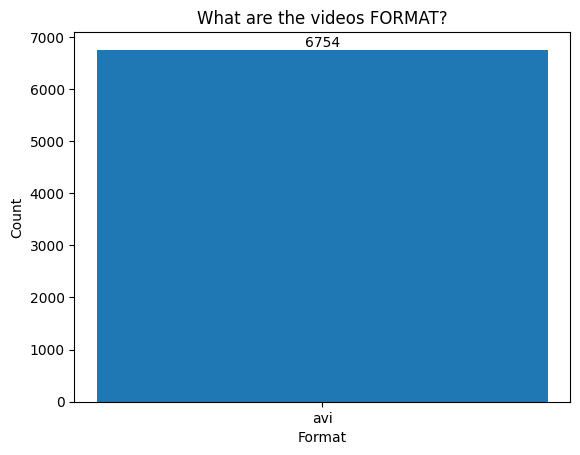

In [27]:
plot_counter(format_count, "What are the videos FORMAT?", "Format", "Count")

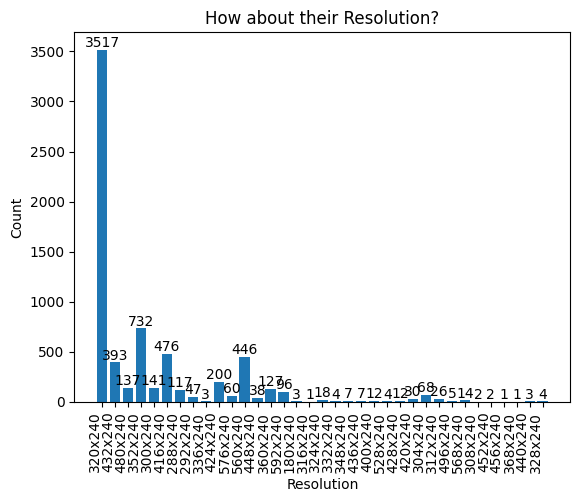

In [33]:
plot_counter(resolution_count, "How about their Resolution?", "Resolution", "Count", rotate=True)

=> Height is always 240, Width varies.

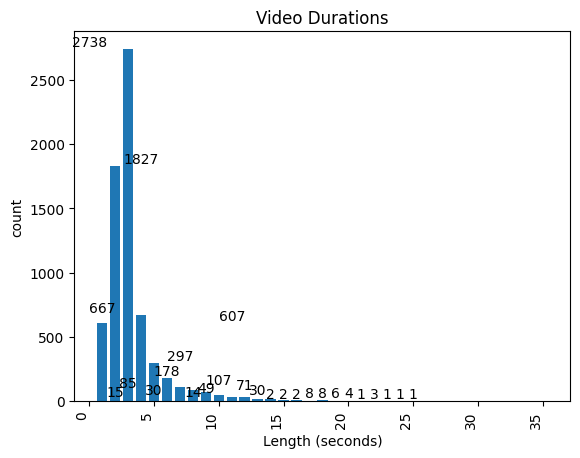

In [34]:
plot_counter(duration_count, "Video Durations", "Length (seconds)", "count", True)

In [1]:
import random

plt.figure(figsize=(30,30))

actions = os.listdir(data_dir)      
counter = 0
for action in actions:
    counter += 1
    list_videos_action = os.listdir(f"{data_dir}/{action}")    #tutti i video di quell'azione
    if True:
        selected_video = random.choice(list_videos_action)
        video_reader = cv2.VideoCapture(f"{data_dir}/{action}/{selected_video}")
        ret, gbrframe = video_reader.read()
        video_reader.release()
        rgb_frame = cv2.cvtColor(gbrframe, cv2.COLOR_BGR2RGB)    #converto immagine da BGR a RGB
        plt.subplot(9,6,counter);plt.imshow(rgb_frame, aspect = "auto");plt.axis("off")
        plt.title(action, fontsize = 20)

NameError: name 'plt' is not defined